<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.13}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Giovanni Alejandri Espinosa \\[6pt]
\textbf{Fecha de realización:} & 03/03/2026
\end{array}

</center>

#PARTE 4: Problema de las 8 Reinas
Colocar 8 reinas en un tablero de ajedrez sin que se ataquen.

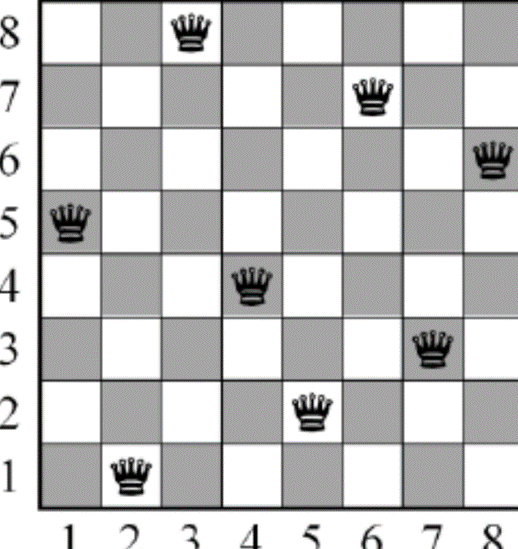

# **1. Definiciones del Problema**
Para explicar esto se puede desglosar así:

- **Estado**: Una lista o vector $L = [c_0, c_1, ..., c_7]$ donde cada índice representa una fila y el valor $c_i$ representa la columna donde está la reina. Un estado parcial tiene algunas reinas colocadas; un estado final tiene las 8 sin ataques.

- **Operadores**: Colocar una reina en la siguiente fila vacía ($fila + 1$) en una columna $j$ tal que $0 \leq j < 8$, siempre que no sea atacada por las reinas previas.

- **Función objetivo**: Verificar si hemos llegado a la fila 8 (todas las reinas colocadas) cumpliendo las restricciones de no ataque.Espacio de Búsqueda: Si no usáramos reglas, sería $8^8$ (16,777,216 estados). Si restringimos a una reina por columna y fila, baja a $8!$ (40,320 estados).

- **¿Es un problema de satisfacción de restricciones (CSP)?** Sí. Las variables son las posiciones de las reinas, el dominio son las casillas del tablero $\{0...7\}$ y las restricciones son que no pueden compartir fila, columna ni diagonal.

- **¿Cómo cambia si usamos A estrella?**  Pasamos de una búsqueda "ciega" (Backtracking/DFS) a una búsqueda informada. A* necesita un costo acumulado $g(n)$ (reinas colocadas) y una heurística $h(n)$. El algoritmo priorizaría expandir ramas que parezcan "más prometedoras".

- **¿Qué heurística podría aplicarse?** Una común es el Número de conflictos potenciales: Contar cuántas casillas quedan "libres" o seguras en las filas restantes. A más casillas libres, mejor es el estado.

# Programa

Solución encontrada:
Reina en fila 0 y columna 0
Reina en fila 1 y columna 4
Reina en fila 2 y columna 7
Reina en fila 3 y columna 5
Reina en fila 4 y columna 2
Reina en fila 5 y columna 6
Reina en fila 6 y columna 1
Reina en fila 7 y columna 3


<Figure size 800x800 with 0 Axes>

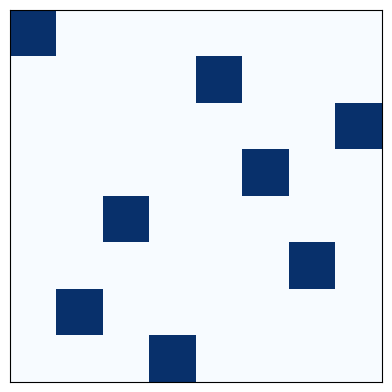

In [ ]:
import matplotlib.pyplot as plt

def es_seguro(tablero, fila, columna):
    # Verificar si es seguro colocar una reina en la fila, columna
    for i in range(fila):
        if tablero[i] == columna or \
           tablero[i] - i == columna - fila or \
           tablero[i] + i == columna + fila:
            return False
    return True

def resolver_8_reinas(tablero, fila):
    if fila == 8:
        return True
    for columna in range(8):
        if es_seguro(tablero, fila, columna):
            tablero[fila] = columna
            if resolver_8_reinas(tablero, fila + 1):
                return True
            tablero[fila] = -1
    return False

def dibujar_tablero(tablero):
    plt.figure(figsize=(8, 8))
    plt.matshow([[tablero[i] == j for j in range(8)] for i in range(8)], cmap="Blues")
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Inicializar el tablero
tablero = [-1] * 8

# Resolver el problema de las 8 reinas
if resolver_8_reinas(tablero, 0):
    print("Solución encontrada:")
    for fila, columna in enumerate(tablero):
        print(f"Reina en fila {fila} y columna {columna}")
    dibujar_tablero(tablero)
else:
    print("No se encontró solución.")

Solución encontrada:

Reina en fila 0 y columna 0
Reina en fila 1 y columna 4
Reina en fila 2 y columna 7
Reina en fila 3 y columna 5
Reina en fila 4 y columna 2
Reina en fila 5 y columna 6
Reina en fila 6 y columna 1
Reina en fila 7 y columna 3

Tiempo de ejecución: 0.0004406550000055631 segundos
Nodos explorados: 114


<Figure size 800x800 with 0 Axes>

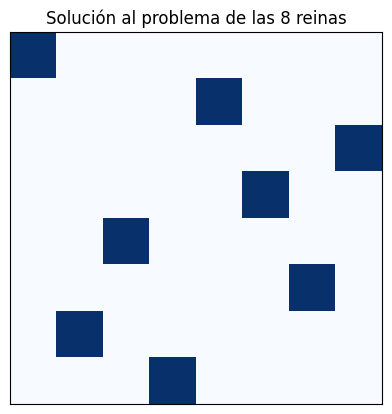

In [1]:
#Código mejorado/optimizado
import matplotlib.pyplot as plt
import time

nodos_explorados = 0

def es_seguro(tablero, fila, columna):
    # Verificar si es seguro colocar una reina
    for i in range(fila):
        if tablero[i] == columna or \
           tablero[i] - i == columna - fila or \
           tablero[i] + i == columna + fila:
            return False
    return True


def resolver_8_reinas(tablero, fila):
    global nodos_explorados
    nodos_explorados += 1

    if fila == 8:
        return True

    for columna in range(8):
        if es_seguro(tablero, fila, columna):
            tablero[fila] = columna

            if resolver_8_reinas(tablero, fila + 1):
                return True

            tablero[fila] = -1

    return False


def dibujar_tablero(tablero):

    plt.figure(figsize=(8, 8))

    matriz = [[tablero[i] == j for j in range(8)] for i in range(8)]

    plt.matshow(matriz, cmap="Blues")

    plt.xticks([])
    plt.yticks([])

    plt.title("Solución al problema de las 8 reinas")

    plt.show()

# Inicializar tablero
tablero = [-1] * 8

# Medición de tiempo
inicio = time.perf_counter()
solucion = resolver_8_reinas(tablero, 0)
fin = time.perf_counter()
tiempo_ejecucion = fin - inicio

if solucion:

    print("Solución encontrada:\n")

    for fila, columna in enumerate(tablero):
        print(f"Reina en fila {fila} y columna {columna}")

    print("\nTiempo de ejecución:", tiempo_ejecucion, "segundos")

    print("Nodos explorados:", nodos_explorados)

    dibujar_tablero(tablero)

else:

    print("No se encontró solución.")

Preguntas:
1. ¿Es un algoritmo óptimo?
  
    El algoritmo implementado utiliza la técnica de backtracking, la cual es una estrategia eficiente para resolver problemas de satisfacción de restricciones como el problema de las 8 reinas. Este método explora sistemáticamente las posibles configuraciones del tablero y descarta aquellas que violan las restricciones del problema. Sin embargo, no se considera completamente óptimo en términos de complejidad computacional, ya que en el peor caso puede explorar una gran cantidad de configuraciones posibles. A pesar de esto, el uso de backtracking permite reducir significativamente el espacio de búsqueda al evitar explorar configuraciones inválidas desde etapas tempranas del proceso. En la práctica, este algoritmo resulta suficientemente eficiente para resolver el problema de las 8 reinas debido al tamaño relativamente pequeño del tablero.
2. Indica la complejidad y espacio de búsqueda con el programa propuesto

    El algoritmo implementado utiliza una estrategia de búsqueda con retroceso (backtracking) que explora diferentes configuraciones posibles del tablero.

    **Complejidad de tiempo**

    En el peor caso, la complejidad temporal del algoritmo es aproximadamente:

    O(N!)

    donde N representa el número de reinas.

    Para el caso específico del problema de las 8 reinas:

    O(8!) = 40320

    Esto significa que el algoritmo podría explorar hasta 40320 configuraciones posibles del tablero en el peor caso, aunque en la práctica el número real es menor debido a las restricciones aplicadas durante la búsqueda.

    **Complejidad de espacio**

    La complejidad de espacio del algoritmo está determinada por:

  *   El arreglo que representa el tablero
  *   La profundidad de la recursión utilizada en el algoritmo.
    Por lo tanto, la complejidad espacial es:

  O(N)

  ya que el tamaño del tablero y la profundidad de la recursión dependen directamente del número de reinas.

3. Indica la limitación del código actual

    Una de las principales limitaciones del código actual es que la función encargada de verificar si una posición es segura recorre todas las reinas colocadas previamente en cada verificación. Esto implica que cada comprobación tiene un costo de tiempo proporcional al número de reinas ya colocadas.

    Además, el programa está diseñado específicamente para resolver el problema con 8 reinas, lo que limita su uso para tableros de mayor tamaño sin realizar modificaciones adicionales al código.

    Otra limitación es que el algoritmo puede explorar un gran número de configuraciones posibles en el peor caso, lo que provoca que el tiempo de ejecución crezca rápidamente cuando el número de reinas aumenta.

4. Realiza una mejora sobre el programa y establece el pseudocodigo previo.

    Una posible mejora consiste en utilizar estructuras de datos auxiliares, como conjuntos (sets), para almacenar las columnas y diagonales que ya se encuentran ocupadas por otras reinas. De esta forma, la verificación de conflictos puede realizarse en tiempo constante

    O(1) en lugar de recorrer todas las posiciones previamente ocupadas.

    Esta optimización reduce el costo de verificación de posiciones y mejora el rendimiento general del algoritmo.

    Pseudocódigo de la mejora

    Algoritmo NReinasOptimizado

        Crear arreglo tablero de tamaño N
        Crear conjunto columnas
        Crear conjunto diagonal1
        Crear conjunto diagonal2

        Función colocar_reina(fila):

        Si fila = N
            imprimir solución
            regresar verdadero

        Para cada columna desde 0 hasta N-1

        Si columna no está en columnas
           y (fila - columna) no está en diagonal1
           y (fila + columna) no está en diagonal2

            colocar reina en tablero[fila]

            agregar columna a columnas
            agregar (fila - columna) a diagonal1
            agregar (fila + columna) a diagonal2

            Si colocar_reina(fila + 1)
                regresar verdadero

            quitar columna de columnas
            quitar (fila - columna) de diagonal1
            quitar (fila + columna) de diagonal2

        regresar falso

Esta mejora permite reducir el costo de verificación de posiciones y hace que el algoritmo sea más eficiente, especialmente cuando se aplica al problema general de N reinas con tableros de mayor tamaño.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>